# Лабоаторная работа 2
## Линейная регрессия

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**1.** Загрузите датасет с успеваемостью студентов (https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)

   Изучите признаки: их шкалу, тип данных, наличие пропусков, распределение. Нашей целевой переменной будет последняя колонка - Performance Index

In [3]:
data = pd.read_csv('Student_Performance.csv')
print("=" * 60)
print(data.info())
print("=" * 60)
print(data.describe())
print("=" * 60)
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB
None
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


Переведите все фичи в числа и сохраните в переменной Х формата np.array. Целевую колонку сохраните в массив y. Для превращения в массив можно использовать df.values. Постройте корреляционную матрицу (это можно сделать как за счет numpy, так и с исходным датафреймом, если выделить из него только числовые колонки)

Разбейте данные на тренировочный и тестовый наборы в отношении 80:20

In [4]:

# перевел все фичи в числа
data['Extracurricular Activities'] = data['Extracurricular Activities'].apply(lambda x: 1 if x == 'Yes' else 0)

X = data.drop('Performance Index', axis=1).values
y = data['Performance Index'].values

numeric_data = data.drop('Performance Index', axis=1)
correction_matrix = numeric_data.corr()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)


Размер X_train: (8000, 5)
Размер X_test: (2000, 5)
Размер y_train: (8000,)
Размер y_test: (2000,)


**2.** На основе базовых классов из sklearn напишите свою линейную регрессию, где коэффициенты находятся с помощью псевдообратной матрицы. Не забудьте про свободный член! Он должен откуда-то появиться.
   $$ w = (X^TX)^{-1} X^T y$$

Второй регрессор напишите с градиентным спуском (мы тут не будем рассматривать стохастический и мини-батч, хотя, если интересно, можете и их заимплементить). Подумайте, как вы будете решать, когда должен остановиться градиентный спуск. По результатам измышлений допишите еще входных параметров в метод \__init__. В качестве функции потерь выберем MSE. В матричной записи она будет выглядеть как $\frac{1}{N}(Xw - y)^T(Xw - y).$ Дифференцируя ее по $w$, получим $$\frac{2}{N} X^T(Xw - y).$$ Формула с псевдообратной матрицей, кстати, получается, если приравнять это к 0 и выразить $w$.

Мы хотим двигаться в направлении, противоположном этому, т.е. эта величина, умноженная на скорость обучения (learning rate), отнимается от текущих весов. Коэффициент 2 из нее поэтому можно и убрать, он войдет в lr, а вот убирать $N$, пожалуй, не стоит.

In [5]:
from sklearn.base import BaseEstimator, RegressorMixin

In [6]:
# напишите свою линейную регрессию, 
# где коэффициенты находятся с помощью псевдообратной матрицы
class PseudoInvRegressor(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.weights_ = None
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X] # [X|1], учли w0
        # $$ w = (X^TX)^{-1} X^T y$$
        self.weights_ = np.linalg.pinv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
        return self
        
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        predictions = X_with_bias @ self.weights_
        return predictions #вектор предсказаний

In [7]:
# Второй регрессор напишите с градиентным спуском
class GradRegressor(BaseEstimator, RegressorMixin):
    # Подумайте, как вы будете решать, когда должен остановиться градиентный спуск. 
    # По результатам измышлений допишите еще входных параметров в метод \__init__
    def __init__(self, learning_rate=0.001, n_iterations=1000, tolerance=1e-5):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations # max количество итераций
        self.tolerance = tolerance
        self.weights_ = None
        self.loss_history_ = []
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        n_samples, n_features = X_with_bias.shape
        
        self.weights_ = np.random.randn(n_features)
        
        prev_loss = float('inf')
        
        for i in range(self.n_iterations): 
            # предсказание
            predications = X_with_bias @ self.weights_
            
            # считаем ошибку
            # $\frac{1}{N}(Xw - y)^T(Xw - y).$
            loss = np.mean((predications - y)**2)
            self.loss_history_.append(loss)
            
            if abs(prev_loss - loss) < self.tolerance:
                print(f"Остановка на {i+1}")
                break
            prev_loss = loss
            
            #  $$\frac{2}{N} X^T(Xw - y).$$ 
            gradient = (2 / n_samples) * X_with_bias.T @ (predications - y)
            # обновляем веса
            
            # Мы хотим двигаться в направлении, противоположном этому, 
            #т.е. эта величина, умноженная на скорость обучения (learning rate),
            # отнимается от текущих весов. Коэффициент 2 из нее поэтому можно и убрать, 
            # он войдет в lr, а вот убирать $N$, пожалуй, не стоит.
            self.weights_ = self.weights_ - self.learning_rate * gradient
            
            if (i % 5 == 0):
                print(f"{i}: MSE = {loss}")
            
        return self
        
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.weights_ #вектор предсказаний

Обучите оба регрессора на загруженных данных. Для второго регрессора придется поэкспериментировать со скоростью и продолжительностью обучения. Постройте график ошибок. 

MSE для PseudoInvRegressor: 4.0826
Веса: [-33.92194622   2.85248393   1.0169882    0.60861668   0.47694148
   0.19183144]
0: MSE = 5710.691419533112
5: MSE = 161.78989563071275
MSE для GradRegressor: 4.0826
Веса: [-33.92194622   2.85248393   1.0169882    0.60861668   0.47694148
   0.19183144]


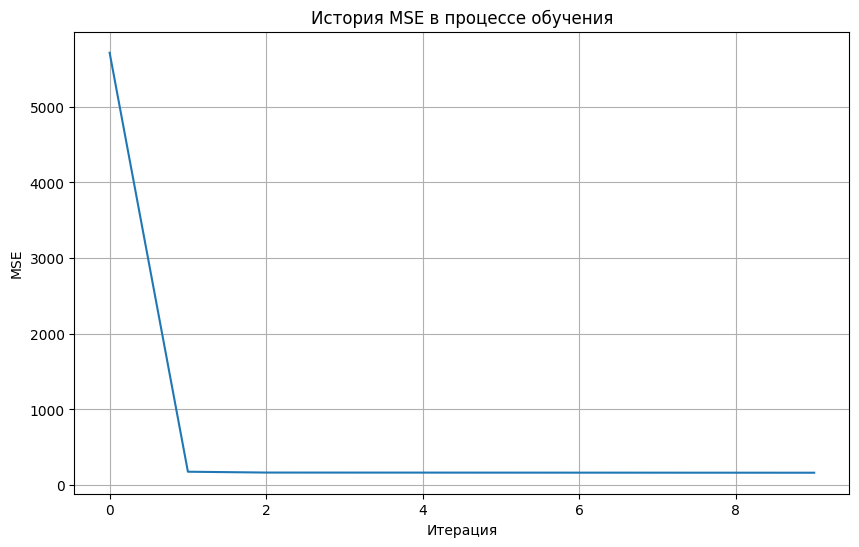

In [8]:
# Обучите оба регрессора на загруженных данных
pseudo_model = PseudoInvRegressor()
pseudo_model.fit(X_train, y_train)
pseudo_preds = pseudo_model.predict(X_test)
pseudo_mse = np.mean((pseudo_preds - y_test)**2)
print(f"MSE для PseudoInvRegressor: {pseudo_mse:.4f}")
print("Веса:", pseudo_model.weights_)


grad_model = GradRegressor(
    # Для второго регрессора придется поэкспериментировать 
    learning_rate=0.0001, # со скоростью и  
    n_iterations=10) # продолжительностью обучения
grad_model.fit(X_train, y_train)
grad_preds = grad_model.predict(X_test)
grad_mse = np.mean((grad_preds - y_test)**2)
print(f"MSE для GradRegressor: {pseudo_mse:.4f}")
print("Веса:", pseudo_model.weights_)

# Постройте график ошибок. 
plt.figure(figsize=(10, 6))
plt.plot(grad_model.loss_history_)
plt.title("История MSE в процессе обучения")
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

**3.** Попробуйте нормализовать или стандартизировать данные, и повторите попытку для обоих регрессоров. Для этого воспользуйтесь скейлерами из sklearn. Метод fit_transform позволяет сразу и настроить параметры скейлера и выполнить масштабирование. **Внимание!** Обучать (fit) скейлер нужно только на тренировочных данных. А потом с полученными на них параметрами применять его к тестовым. **Еще внимание!** Если в вашей матрице $X$ был столбик для свободного члена, после масштабирования он станет нулевым. Это не то, чего нам бы хотелось, это надо пофиксить

Итак, что изменилось?

Контрольные вопросы: зачем масштабировать данные? Когда это обязательно, когда не очень? Надо ли масштабировать $y$? Зачем градиентный регрессор (а он имплементирован не только вами, но и авторами sklearn), если можно найти псевдообратную матрицу, которая является оптимальным решением?

MSE для псевдообратного регрессора (scaled): 4.0826
0: MSE = 3378.785761632737
5: MSE = 2762.0047199963938
10: MSE = 2257.9571569773443
15: MSE = 1846.0372584916665
20: MSE = 1509.40573988008
25: MSE = 1234.301340400816
30: MSE = 1009.4781777122519
35: MSE = 825.7459541823442
40: MSE = 675.5942130621034
45: MSE = 552.8852797869421
50: MSE = 452.60333251001435
55: MSE = 370.6493413094039
60: MSE = 303.67349122590383
65: MSE = 248.938237095972
70: MSE = 204.20639073544797
75: MSE = 167.64966463258475
80: MSE = 137.7739327868233
85: MSE = 113.35815289199839
90: MSE = 93.40445266450281
95: MSE = 77.09733960282608
100: MSE = 63.7703665028316
105: MSE = 52.878889898361884
110: MSE = 43.97780771552566
115: MSE = 36.70336600860063
120: MSE = 30.758291010751165
125: MSE = 25.899638686711523
130: MSE = 21.928865076539115
135: MSE = 18.683711512521533
140: MSE = 16.031572987845976
145: MSE = 13.86407858954575
150: MSE = 12.092662458768576
155: MSE = 10.64494423457212
160: MSE = 9.461771028910498


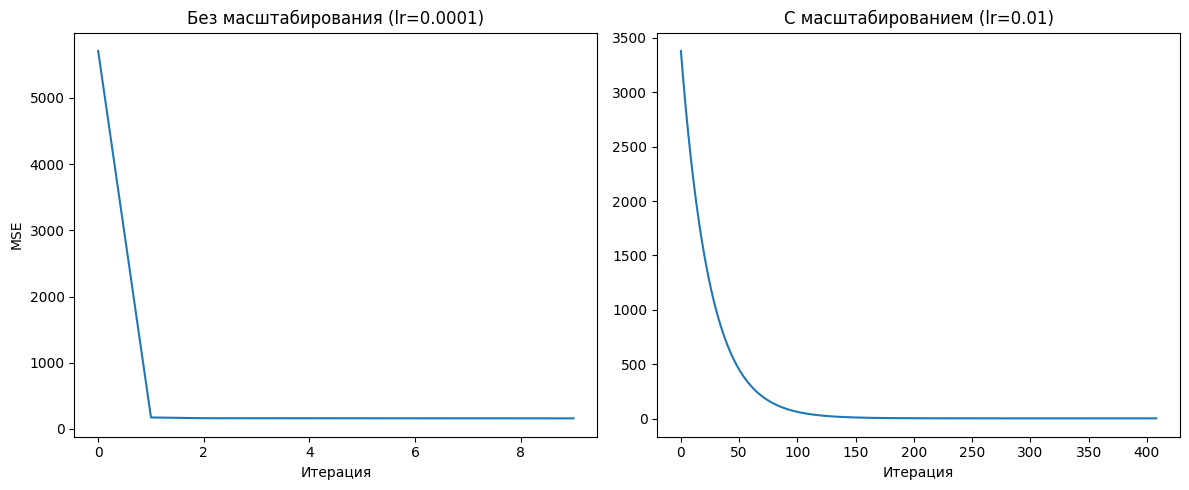

In [9]:
# Попробуйте нормализовать или стандартизировать данные, и повторите попытку для обоих регрессоров.

# Для этого воспользуйтесь скейлерами из sklearn.
# на ваш выбор
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()

# Метод fit_transform позволяет сразу 
# и настроить параметры скейлера и выполнить масштабирование
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pseudo_model_scaled = PseudoInvRegressor()
pseudo_model_scaled.fit(X_train_scaled, y_train)
pseudo_preds_scaled = pseudo_model_scaled.predict(X_test_scaled)
pseudo_mse_scaled = np.mean((pseudo_preds_scaled - y_test)**2)
print(f"MSE для псевдообратного регрессора (scaled): {pseudo_mse_scaled:.4f}")

grad_model_scaled = GradRegressor(
    learning_rate=0.01, 
    n_iterations=1000)
grad_model_scaled.fit(X_train_scaled, y_train)
grad_preds_scaled = grad_model_scaled.predict(X_test_scaled)
grad_mse_scaled = np.mean((grad_preds_scaled - y_test)**2)
print(f"MSE для градиентного регрессора (scaled): {grad_mse_scaled:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(grad_model.loss_history_)
plt.title("Без масштабирования (lr=0.0001)")
plt.xlabel("Итерация"); plt.ylabel("MSE")

plt.subplot(1, 2, 2)
plt.plot(grad_model_scaled.loss_history_)
plt.title("С масштабированием (lr=0.01)")
plt.xlabel("Итерация")
plt.tight_layout()
plt.show()



= Итак, что изменилось?
из явного 
- изменился график, он стал гладким.
- можно увеличить шаг lt. в данном прогоне он у меня в 100 раз больше (0.01), чем я использовал в Без масштабирования (с таким шагом для данных Без масштабирования MSE уходили в бесконечность)
- Градиентом получилось найти даже более оптимальное решение. более точное, чем аналитическим решением (по всей видимости это связано с вычислениями чисел с плавающей точкой)

Контрольные вопросы: 

= Зачем масштабировать данные? Когда это обязательно, когда не очень?
- Масштабирование данных, это процесс приведения признаков к "подобному" виду. к примеру -- два параметра, один от 1 до 10, другой от 1 до 100. Изменение на 1 одного и другого -- это 10% и 1% соответственно. то есть, один из параметров может считаться более "важным" (разные веса признаков). и чтобы этого избежать, занимаются масштабированием данных. 
- это особенно может быть проблемой для тех, кто использует работу с градиентами -- шаги вдоль признаков могут быть большими/маленькими из-за проблемы с их масштабом. и регуляризацией тоже.
- если же такой нужды в масштабе нет (например, категории тд), то и масштабировать не нужно

= Надо ли масштабировать $y$? 
- технически нет, ведь: если посмотреть на уравнение $y = X*w + w_0$, то если промасштабировать $X$, то измениться и матрица весов $w$ (модель найдет его другой), и в результате будет все равно получиться тот же $y$.

= Зачем градиентный регрессор (а он имплементирован не только вами, но и авторами sklearn), если можно найти псевдообратную матрицу, которая является оптимальным решением?
- ассимтотическая сложность вычисления псевдообратной O(количество признаков^3) и O(количество признаков^2) памяти. А градиентные методы просят перемножение матрицы и вектора, что занимает O(n) / O(n log n)
- когда данные "доходят", то придется пересчитывать псевдообратную (либо каждый раз, либо "реже"). а градиентный способ позволяет обновлять постепенно
- из-за плохой обусловленности вычисление псевдообратной может быть неустойчивым 

**4.** Добавим возможность l1 и l2 регуляризации. Это означает, что функция потерь примет вид

$$\frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_1\sum_{j=1}^m |w_j| + \lambda_2\sum_{j=1}^m w_j^2,$$

где $\lambda_1$, $\lambda_2$ отвечают за выраженность l1 и l2 регуляризаций и могут их выключить, будучи равными 0.

Здесь мы сталкиваемся с проблемой в случае псевдообратного решения - из-за того, что модуль недифференцируем в 0, мы, вообще-то, не можем получить одну конечную формулу для решения. Но для l2 все в порядке. 

Итак, для **псевдообратного регрессора** выведите новую формулу с учетом l2-регуляризации. Выводится она из тех соображений, что искомое $w$ - это точка, где достигается экстремум функции потерь, т.е. равна 0 ее производная. Добавьте в класс этого регрессора l2-регуляризацию.

Для **градиентного регрессора** добавьте обе регуляризации (производной модуля будем считать $sgn$).

```
Итак, для **псевдообратного регрессора** выведите новую формулу с учетом l2-регуляризации.
```
то есть, мы берем исходную формулу
$$Loss(w) = \frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_1\sum_{j=1}^m |w_j| + \lambda_2\sum_{j=1}^m w_j^2,$$
и "выключаем" l1
$$Loss(w) = \frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_2\sum_{j=1}^m w_j^2,$$
в матричном виде
$$ Loss(w) = (Xw - y)^T(Xw - y) + \lambda w^Tw $$

```
Выводится она из тех соображений, что искомое $w$ - это точка, где достигается экстремум функции потерь, т.е. равна 0 ее производная.
```
$$ \frac{\partial Loss}{\partial w} = \frac{\partial}{\partial w} \left( (Xw - y)^T(Xw - y) \right) + \frac{\partial}{\partial w} \left( \lambda w^Tw \right) = 0 $$
$$ 2X^T(Xw - y) + 2\lambda w = 0 $$
$$ X^T(Xw - y) + \lambda w = 0 $$
$$ X^TXw - X^Ty + \lambda w = 0 $$
$$ X^TXw + \lambda w = X^Ty $$
$$ (X^TX + \lambda I)w = X^Ty $$

Итого
$$ w = (X^TX + \lambda I)^{-1} X^Ty $$

```
Добавьте в класс этого регрессора l2-регуляризацию.
```

In [10]:
class PseudoInvRegressorL2(BaseEstimator, RegressorMixin):
    def __init__(self, l2_lambda):
        self.l2_lambda = l2_lambda
        self.weights_ = None
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        n_samples, n_features = X_with_bias.shape
        
        I = np.eye(n_features)
        
        I[0, 0] = 0 # w0 не "штрафуется"
        term1 = np.linalg.inv(X_with_bias.T @ X_with_bias + self.l2_lambda * I)
        term2 = X_with_bias.T @ y
        self.weights_ = term1 @ term2
        
        return self
    
    def predict(self, X): 
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.weights_

```
Для **градиентного регрессора** добавьте обе регуляризации (производной модуля будем считать $sgn$).
```
исходная функция
$$Loss(w) = \frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_1\sum_{j=1}^m |w_j| + \lambda_2\sum_{j=1}^m w_j^2,$$

для нее
$$\nabla Loss = \frac{2}{N} X^T(Xw - y) + \lambda_1 \cdot \text{sgn}(w) + 2\lambda_2 w$$


In [11]:
class GradRegressorWithRegularization(BaseEstimator, RegressorMixin): 
    def __init__(self, learning_rate=0.001, n_iterations=1000, l1_lambda=0.0, l2_lambda=0.0, tolerance=1e-5):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations # max количество итераций
        self.tolerance = tolerance
        self.weights_ = None
        self.loss_history_ = []
        self.l1_lambda = l1_lambda
        self.l2_lambda = l2_lambda
        self.n_iter_ = None
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        n_samples, n_features = X_with_bias.shape
        self.weights_ = np.random.randn(n_features)
        
        prev_loss = float('inf')
        
        for i in range(self.n_iterations):
            predictions = X_with_bias @ self.weights_
            
            mse_loss = np.mean((predictions - y)**2)
            l1_loss = self.l1_lambda * np.sum(np.abs(self.weights_[1:]))
            l2_loss = self.l2_lambda * np.sum(self.weights_[1:]**2)
            loss = mse_loss + l1_loss + l2_loss
            
            self.loss_history_.append(loss)
            
            if abs(prev_loss - loss) < self.tolerance:
                print(f"Остановка на итерации {i+1}")
                break
            prev_loss = loss
            
            # $$\nabla Loss = \frac{2}{N} X^T(Xw - y) + \lambda_1 \cdot \text{sgn}(w) + 2\lambda_2 w$$
            # $$\nabla \frac{2}{N} X^T(Xw - y) $$
            mse_gradient = (2/n_samples) * X_with_bias.T @ (predictions - y)
            
            weights_for_grad = self.weights_.copy()
            weights_for_grad[0] = 0
        
            # $$\lambda_1 \cdot \text{sgn}(w)$$
            l1_gradient = self.l1_lambda * np.sign(weights_for_grad)
            # $$2\lambda_2 w$$
            l2_gradient = self.l2_lambda * weights_for_grad
            
            gradient = mse_gradient + l1_gradient + l2_gradient
            
            self.weights_ = self.weights_ - self.learning_rate * gradient
            print(f"Итерация {i}: Loss = {loss}")
        self.n_iter_ = i + 1
            
        return self
    
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.weights_                

**5.** Обучите ваши регрессоры с этими новыми настройками. Рассмотрите 3 случая: 
- псевдообратные регрессор с l2
- градиентный регрессор с l1
- градиентный регрессор с l2

Подберите какие-то лямбды, дающие адекватный результат. Потом загрузите регрессоры из sklearn и обучите их с теми же (насколько это возможно) настройками. Сравните полученные веса и ошибку на тренировочном и тестовых множествах (выведите их куда-нибудь в одно место, вместе с параметрами, чтоб красиво. Можно, например, собрать из них маленький датафрейм)

Когда пойдете читать справку для Lasso и Ridge, обратите внимание на описываемые способы решения: в Ridge(l2) есть несколько опций, в том числе детерминированных; в Lasso(l1) используется координатный спуск.

Контрольный вопрос: почему про L1 говорят, что он отбирает признаки, а L2 - нет?

In [12]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso, Ridge

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Подберите какие-то лямбды, дающие адекватный результат.
L2_LAMBDA = 0.01
L1_LAMBDA = 0.1

results = []

# псевдообратные регрессор с l2
my_pseudo = PseudoInvRegressorL2(l2_lambda=L2_LAMBDA)
my_pseudo.fit(X_train_scaled, y_train)
train_predicitons = my_pseudo.predict(X_train_scaled)
test_predictions = my_pseudo.predict(X_test_scaled)
results.append({
    "модель": "Моя PseudoInv L2",
    "Lambda": L2_LAMBDA,
    "итерации": "0",
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": my_pseudo.weights_
})

# градиентный регрессор с l1
my_grad_l1 = GradRegressorWithRegularization(
    learning_rate=0.01, 
    n_iterations=1000, 
    l1_lambda=L1_LAMBDA)
my_grad_l1.fit(X_train_scaled, y_train)
train_predicitons = my_grad_l1.predict(X_train_scaled)
test_predictions = my_grad_l1.predict(X_test_scaled)

results.append({
    "модель": "Моя Grad с L1",
    "Lambda": L1_LAMBDA,
    "итерации": my_grad_l1.n_iter_,
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": my_grad_l1.weights_
})

# градиентный регрессор с l2
my_grad_l2 = GradRegressorWithRegularization(
    learning_rate=0.01, 
    n_iterations=1000, 
    l2_lambda=L2_LAMBDA)
my_grad_l2.fit(X_train_scaled, y_train)
train_predicitons = my_grad_l2.predict(X_train_scaled)
test_predictions = my_grad_l2.predict(X_test_scaled)

results.append({
    "модель": "Моя Grad с L2",
    "Lambda": L2_LAMBDA,
    "итерации": my_grad_l2.n_iter_,
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": my_grad_l2.weights_
})

# Потом загрузите регрессоры из sklearn 
# и обучите их с теми же (насколько это возможно) настройками.

# Sklearn
sklearn_ridge = Ridge(alpha=L2_LAMBDA)
sklearn_ridge.fit(X_train_scaled, y_train)
train_predicitons = sklearn_ridge.predict(X_train_scaled)
test_predictions = sklearn_ridge.predict(X_test_scaled)

sklearn_ridge_weights = np.insert(sklearn_ridge.coef_, 0, sklearn_ridge.intercept_)
results.append({
    "модель": "Sklearn Ridge",
    "Lambda": L2_LAMBDA,
    "итерации": "0",
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": sklearn_ridge_weights
})

sklearn_lasso = Lasso(alpha=L1_LAMBDA)
sklearn_lasso.fit(X_train_scaled, y_train)
train_predicitons = sklearn_lasso.predict(X_train_scaled)
test_predictions = sklearn_lasso.predict(X_test_scaled)

sklearn_lasso_weights = np.insert(sklearn_lasso.coef_, 0, sklearn_lasso.intercept_)
results.append({
    "модель": "Sklearn Lasso",
    "Lambda": L1_LAMBDA,
    "итерации": sklearn_lasso.n_iter_,
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": sklearn_lasso_weights
})

# Сравните полученные веса и ошибку на тренировочном 
# и тестовых множествах (выведите их куда-нибудь в одно место, 
# вместе с параметрами, чтоб красиво.
# Можно, например, собрать из них маленький датафрейм)
df_results = pd.DataFrame(results)
df_results['отформатированные веса'] = df_results['веса'].apply(lambda w: np.round(w, 2))
display(df_results[['модель', 'Lambda', 'итерации', 'тренировочная MSE', 'тест MSE', 'отформатированные веса']])

Итерация 0: Loss = 3715.83891011524
Итерация 1: Loss = 3568.8992454229733
Итерация 2: Loss = 3427.905999183964
Итерация 3: Loss = 3292.521982440231
Итерация 4: Loss = 3162.4974875376847
Итерация 5: Loss = 3037.618360151953
Итерация 6: Loss = 2917.680979550907
Итерация 7: Loss = 2802.48978327032
Итерация 8: Loss = 2691.856948198627
Итерация 9: Loss = 2585.6020842835187
Итерация 10: Loss = 2483.5519403608178
Итерация 11: Loss = 2385.5401216258506
Итерация 12: Loss = 2291.406818286522
Итерация 13: Loss = 2200.99854495554
Итерация 14: Loss = 2114.167890356753
Итерация 15: Loss = 2030.7732769373797
Итерация 16: Loss = 1950.6787299940768
Итерация 17: Loss = 1873.7536559363025
Итерация 18: Loss = 1799.8726293253364
Итерация 19: Loss = 1728.9151883416337
Итерация 20: Loss = 1660.7656383469348
Итерация 21: Loss = 1595.3128632207538
Итерация 22: Loss = 1532.4501441635573
Итерация 23: Loss = 1472.0749856711075
Итерация 24: Loss = 1414.0889483961616
Итерация 25: Loss = 1358.397488624928
Итерация 2

,модель,Lambda,итерации,тренировочная MSE,тест MSE,отформатированные веса
0,Моя PseudoInv L2,0.01,0,4.169736,4.082634,"[55.31, 7.4, 17.64, 0.3, 0.81, 0.55]"
1,Моя Grad с L1,0.10,411,4.183109,4.115650,"[55.3, 7.35, 17.58, 0.25, 0.76, 0.5]"
2,Моя Grad с L2,0.01,366,4.182361,4.115231,"[55.28, 7.36, 17.54, 0.3, 0.81, 0.55]"
3,Sklearn Ridge,0.01,0,4.169736,4.082634,"[55.31, 7.4, 17.64, 0.3, 0.81, 0.55]"
4,Sklearn Lasso,0.10,3,4.219624,4.175297,"[55.31, 7.3, 17.54, 0.2, 0.71, 0.45]"


```
Когда пойдете читать справку для Lasso и Ridge, обратите внимание на описываемые способы решения: в Ridge(l2) есть несколько опций, в том числе детерминированных; в Lasso(l1) используется координатный спуск.
```

```
Контрольный вопрос: почему про L1 говорят, что он отбирает признаки, а L2 - нет?
```
"отобрать" это значит, что признак зануляется 
то есть L1 может занулить признак, а L2 не занулит его

### Почему?
градиент для L1 -- он постоянный, а градиент для L2 -- он пропорционален $$w$$
то есть 
$$\nabla Loss(w) = MSE(w) + L1(w) + L2(w)$$
где
$$\nabla MSE(w) = \frac{2}{N} X^T(Xw - y)$$
$$\nabla L1(w) = \lambda_1 \cdot \text{sgn}(w)$$
$$\nabla L2(w) = 2\lambda_2 w$$
L2 стремит w_i к 0, но не делает его нулевым. а L1 он стабильно уменьшает вес И если тот стал 0, то больше с ним ничего не делает (sign(0) = 0)

**6.** Почитайте справку для класса SGDRegressor и сообразите, как сделать так, чтобы он оптимизировал MAE, а не MSE. Обучите два регрессора - один с абсолютной ошибкой, другой с квадратичной. Сравните веса, значения обеих ошибок на тренировочном и тестовом наборах

MSE (Mean Squared Error) (чем больше ошибка, тем сильнее она наказывается): $$ \frac{1}{N}\sum (y_i - \hat{y}_i)^2 $$
MAE (Mean Absolute Error)(ошибки наказываются пропорционально): $$ \frac{1}{N}\sum |y_i - \hat{y}_i| $$

# Что я выбрал для MAE и MSE
сделал я вот что
```python
SGDRegressor(loss='squared_error', random_state=42, max_iter=1000, tol=1e-3)
SGDRegressor(loss='epsilon_insensitive', random_state=42, max_iter=1000, epsilon=0)
```
формулы из документации
[тут](https://scikit-learn.org/stable/modules/sgd.html#sgd-mathematical-formulation)
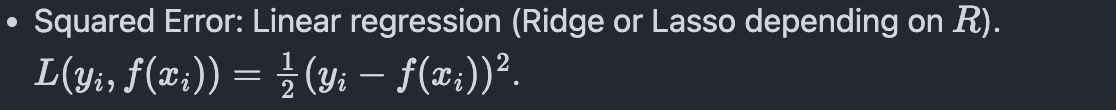
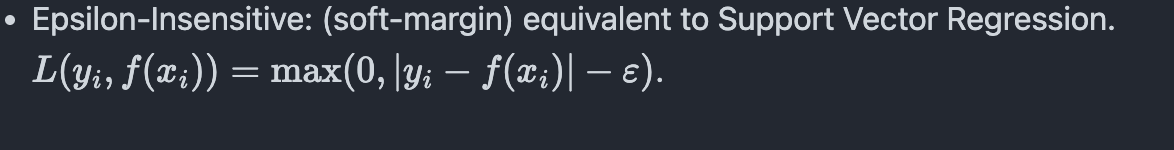


In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd

# MSE
sgd_mse = SGDRegressor(loss='squared_error', random_state=42, max_iter=1000, tol=1e-3)
sgd_mse.fit(X_train_scaled, y_train)

# Почитайте справку для класса SGDRegressor и сообразите, как сделать так, чтобы он оптимизировал MAE, а не MSE. 
# MAE
sgd_mae = SGDRegressor(loss='epsilon_insensitive', random_state=42, max_iter=1000, epsilon=0)
sgd_mae.fit(X_train_scaled, y_train)

results_mae_vs_mse = []

# MSE
train_preds_mse = sgd_mse.predict(X_train_scaled)
test_preds_mse = sgd_mse.predict(X_test_scaled)
weights_mse = np.insert(sgd_mse.coef_, 0, sgd_mse.intercept_)
results_mae_vs_mse.append({
    "модель": "MSE",
    "тренировочная MSE": mean_squared_error(y_train, train_preds_mse),
    "тест MSE": mean_squared_error(y_test, test_preds_mse),
    "тренировочная MAE": mean_absolute_error(y_train, train_preds_mse),
    "тест MAE": mean_absolute_error(y_test, test_preds_mse),
    "веса": np.round(weights_mse, 2)
})

# MAE
train_preds_mae = sgd_mae.predict(X_train_scaled)
test_preds_mae = sgd_mae.predict(X_test_scaled)
weights_mae = np.insert(sgd_mae.coef_, 0, sgd_mae.intercept_)
results_mae_vs_mse.append({
    "модель": "MAE",
    "тренировочная MSE": mean_squared_error(y_train, train_preds_mae),
    "тест MSE": mean_squared_error(y_test, test_preds_mae),
    "тренировочная MAE": mean_absolute_error(y_train, train_preds_mae),
    "тест MAE": mean_absolute_error(y_test, test_preds_mae),
    "веса": np.round(weights_mae, 2)
})

df_comparison = pd.DataFrame(results_mae_vs_mse)
display(df_comparison)

,модель,тренировочная MSE,тест MSE,тренировочная MAE,тест MAE,веса
0,MSE,4.172648,4.085784,1.620282,1.611472,"[55.32, 7.35, 17.64, 0.3, 0.81, 0.55]"
1,MAE,4.172280,4.088634,1.618943,1.612473,"[55.28, 7.41, 17.61, 0.32, 0.81, 0.53]"


что мы можем видеть 
- результаты очень похожи
- каждая модель показывает себя лучше в своей метрике (MSE минимизировала MSE, а MAE MAE)
- и отсюда можно сделать вывод, что минимумы функций могут быть где-то рядом. и это вероятно связанно с искуственностью наших данных 





**7.** В датасете со студентами у нас был нормально распределенный таргет. Вообще-то это как бы не обязательно (нормальному распределению должны следовать ошибки; да и это тоже необязательно - смотря какие выводы вы хотите потом сделать о модели), но в некоторых туториалах можно встретить и такое требование. А еще в некоторых - требование нормального распределения фичей. Математического пояснения этому обычно не дается, а говорится что-то вроде "модель эффективнее обучается на нормально распределенных данных". 

Загрузите датасет с ценами медстраховки (https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset ). Масштабируйте данные, предобработайте категориальные признаки. Попробуйте скорректировать а) распределение целевой переменной б) распределения не бинарных фичей до нормального. На этих данных обучите модели настолько хорошо, насколько сможете, и сравните их качество с моделями без подобных преобразований. Сравнивать будем по MSE на тесте (20%), при этом если вы преобразовали целевую переменную, не забудьте преобразовать ее обратно прежде чем вычислять эту MSE для сравнения

**Внимание!** Корректировка распределения проводится по тренировочным данным. По ним вы определяете некое преобразование, которое потом будет применяться на тест

**8.** Добавим в наши данные немного мусора. Сделайте колонку с id пациента (числа от 0 до ...) и его любимым цветом (случайный цвет, заданный тремя параметрами RGB, распределение случайных величин - на ваше усмотрение). Проведите предобработку данных, которую посчитаете нужной, только не выбрасывайте наши мусорные колонки. Чтобы поменьше заниматься подбором параметров, обучим следующием модели:

- псевдообратный регрессор
- псевдообратный регрессор с L2 регуляризацией
- псевдообратный регрессор, но мы выбросили id
- псевдообратный регрессор с L2 регуляризацией, но мы выбросили id
- псевдообратный регрессов, но мы выбросили и id, и цвета
- псевдообратный регрессор с L2 регуляризацией, но мы выбросили и id, и цвета

Вычислите для каждой модели $R^2$ и скорректированный $R^2$ на тестовом и на тренировочном множествах, сведите в табличку. Какие выводы можно сделать из увиденного? 